## ENTRENAMIENTO

In [2]:
from preprocesamiento import *
from entrenamiento import *

from sklearn.model_selection import train_test_split

df = cargar_preparar_datos('../data/INM_estatal_dic25_clean.csv')

X, y = separar_features_target(df)

preprocessor = construir_preprocesador(X)

# 80-20 y semilla aleatoria fija
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

grid = entrenar_random_forest(
    X_train,
    y_train,
    preprocessor
)

mejor_modelo = grid.best_estimator_

print(grid.best_params_)
print(grid.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
{'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}
0.8822911043016309


## Evaluación

,Metrica,Valor
0,MAE,0.383849
1,MSE,0.475825
2,RMSE,0.689801
3,R2,0.879764


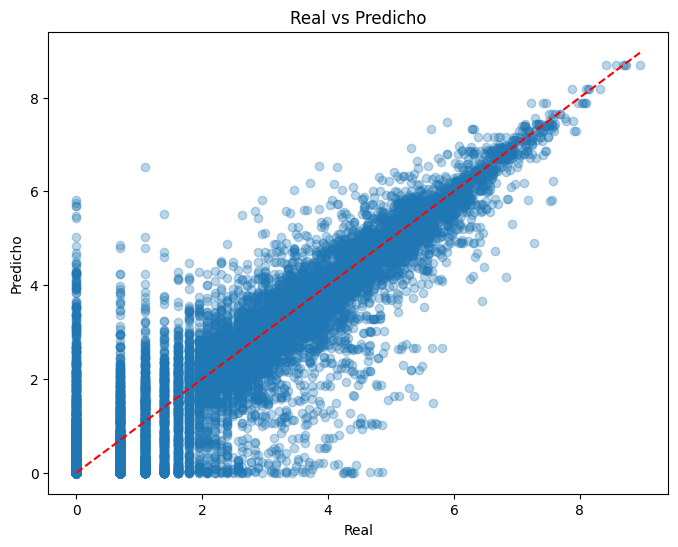

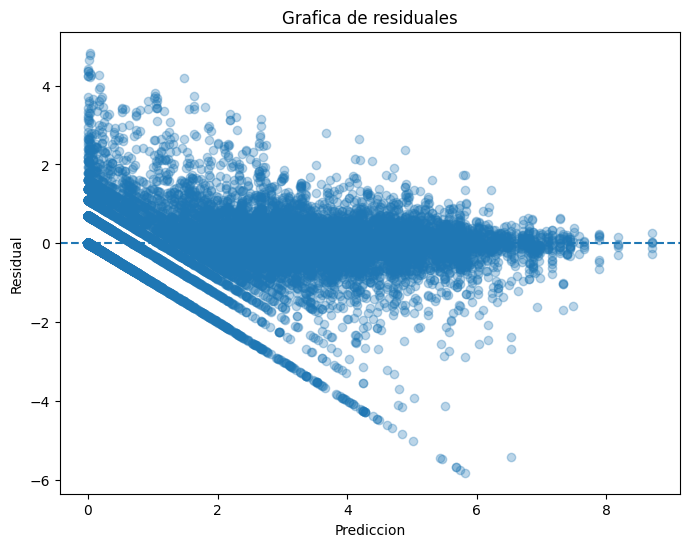

In [3]:
from evaluacion import *

metricas, y_pred = evaluar_modelo(mejor_modelo, X_test, y_test)

display(metricas)

grafica_predicciones(y_test, y_pred)

grafica_residuales(y_test, y_pred)

## Comparación con línea base

In [5]:
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline

baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

baseline.fit(X_train, y_train)

baseline_metricas, _ = evaluar_modelo(baseline, X_test, y_test)

display(baseline_metricas)

,Metrica,Valor
0,MAE,1.731096
1,MSE,3.957466
2,RMSE,1.989338
3,R2,-0.000006


## Persistencia

In [6]:
from persistencia import *

guardar_modelo(mejor_modelo, "modelo_incidencia_delictiva.joblib")

Modelo guardado en modelo_incidencia_delictiva.joblib
